# 00 · Hugging Face CLI로 모델과 이미지 준비하기
**실행 위치: Codespaces CPU.** 이 노트북은 Colab GPU를 생성하지 않습니다.

오늘의 흐름은 **모델 다운로드 → Colab GPU 연결 → 추론 → 추가 학습 → 결과 회수**입니다.
모델 내부의 Attention 계산은 Transformers가 담당합니다. 실습은 이 폴더의 00·01·02 노트북 순서로 진행합니다.

Codespaces의 자동 환경 설치가 끝나면 아래 안내에 따라 커널을 **Vision AI (Codespaces CPU)**로 선택하세요. 자동 설치에 문제가 있을 때 `bash scripts/setup.sh`로 다시 준비합니다.
각 셀에서 공개 라이브러리를 직접 가져오며 별도의 수업 패키지를 설치하지 않습니다.

## 시작 전 · 내 Codespace 열기

개인 PC에 라이브러리를 하나씩 설치하는 대신, 이 저장소의 **devcontainer 설정**으로 수업용 개발 환경을 만듭니다. 설정 파일은 함께 쓰지만 각 학생은 본인 계정의 Codespace에서 작업합니다.

1. [수업 저장소](https://github.com/yblee110/vision-ai-notebook)를 **Fork**해 본인 계정으로 복사합니다.
2. **본인이 Fork한 저장소**에서 **Code → Codespaces → Create codespace on main**을 누릅니다. 머신을 선택한다면 **2코어·8GB**를 사용합니다.
3. VS Code 화면이 떠도 설치가 진행 중일 수 있습니다. `postCreateCommand`의 자동 설치가 끝나고 **준비 완료** 안내가 나올 때까지 기다립니다.
4. 이 노트북을 열고 오른쪽 위 **커널 선택 → Jupyter 커널 → Vision AI (Codespaces CPU)**를 고릅니다. 메뉴에 바로 보이지 않으면 **다른 커널 선택**에서 찾아봅니다.

**00번은 Codespaces CPU에서 실행합니다.** Colab GPU는 이후 별도로 연결합니다. Codespace를 만들거나 아래 환경을 확인하는 과정에서는 Google 로그인이나 Colab GPU 할당이 일어나지 않습니다.

## devcontainer 설정은 어떤 일을 할까요?

| 파일 | 이 저장소의 설정 | 내가 확인할 점 |
|---|---|---|
| [`.devcontainer/devcontainer.json`](../../.devcontainer/devcontainer.json) | 사용할 Dockerfile, 2코어·8GB·20GB 요구 조건, 자동 설치 명령, Python·Jupyter 확장 | 환경 준비의 시작점입니다. |
| [`.devcontainer/Dockerfile`](../../.devcontainer/Dockerfile) | Python 3.12 기반 이미지와 `uv` 0.12.9 | Codespace 안의 기본 도구를 정합니다. |
| [`scripts/setup.sh`](../../scripts/setup.sh) | `.venv` 생성, 라이브러리 설치, `Vision AI (Codespaces CPU)` 커널 등록 | 생성 직후 자동으로 실행됩니다. 이미 끝났다면 다시 설치할 필요가 없습니다. |
| [`requirements/codespaces.txt`](../../requirements/codespaces.txt) | Codespaces에서 쓸 공개 라이브러리 목록 | GPU용 PyTorch 설치는 Colab에서 별도로 합니다. |
| [`.vscode/settings.json`](../../.vscode/settings.json) | 기본 Python 경로를 `.venv/bin/python`으로 지정 | 노트북의 커널 선택과 터미널의 Python 경로를 함께 확인합니다. |

실제 설정에서 일부만 발췌한 예시입니다. **설명용이므로 코드 셀로 실행하거나 전체 설정 파일을 이 내용으로 바꾸지 않습니다.**

```json
{
  "build": { "dockerfile": "Dockerfile", "context": ".." },
  "postCreateCommand": "bash scripts/setup.sh",
  "hostRequirements": { "cpus": 2, "memory": "8gb", "storage": "20gb" }
}
```

```dockerfile
FROM ghcr.io/astral-sh/uv:0.12.9 AS uv
FROM mcr.microsoft.com/devcontainers/python:1-3.12-bookworm
```

이 설정은 주요 도구와 라이브러리 버전을 공유하기 위한 것입니다. 모든 컴퓨터의 결과가 언제나 완전히 같다는 보장은 아닙니다. [GitHub devcontainer 설명](https://docs.github.com/en/codespaces/setting-up-your-project-for-codespaces/adding-a-dev-container-configuration/introduction-to-dev-containers)

## 셀을 실행하기 전에 환경 확인하기

Codespaces의 **터미널**을 열고 `.vision-lab-root`가 있는 프로젝트 최상위에서 실행합니다. 다음 명령은 노트북 코드 셀에 붙여 넣지 않습니다.

```bash
source .venv/bin/activate
python scripts/doctor.py
python -c "import sys; print(sys.executable)"
```

예상되는 상태는 **Python 3.12**, 프로젝트 안의 **`.venv/bin/python`**, 준비된 HF CLI·Colab CLI입니다. 출력의 프로젝트 경로는 학생마다 달라질 수 있습니다. 이어지는 첫 코드 셀에서도 `Python:` 경로가 이 가상환경을 가리키는지 확인합니다.

- `.venv`가 없거나 자동 설치가 실패했다면, 오류 내용을 확인한 뒤 터미널에서 `bash scripts/setup.sh`를 실행합니다.
- `uv`를 찾지 못하거나 Dockerfile·devcontainer 설정을 바꿨다면, 수정한 노트북과 필요한 결과를 먼저 저장·백업하고 명령 팔레트에서 **Codespaces: Rebuild Container**를 실행합니다. 준비가 끝나면 커널을 다시 선택합니다.
- `ModuleNotFoundError`가 나면 먼저 잘못된 Python 커널을 선택했는지 확인합니다. 코드 셀마다 임의로 설치 명령을 추가하기 전에 `doctor.py` 결과를 살펴봅니다.

노트북 수정 내용은 Git에 커밋해 보관하고, 개인 사진·다운로드한 모델·실행 결과는 따로 백업합니다. `.gitignore`에 있는 `.venv`, `.cache`, `.local-state`, `data`, 모델·결과 폴더는 업로드 대상이 아닙니다. 토큰과 로그인 정보도 노트북이나 커밋에 넣지 않습니다.

준비가 끝났다면 아래 셀부터 순서대로 실행합니다. 00번을 마친 뒤에는 [Pipeline 추론·셸 시연 안내](../pipeline-guide.md)에서 짧은 추론을 먼저 실행해 보고, 01·02번의 AI 코딩 문제로 이어갈 수 있습니다.

참고: [Codespaces 컨테이너 재빌드와 파일 보존](https://docs.github.com/en/codespaces/developing-in-a-codespace/rebuilding-the-container-in-a-codespace).

## 라이브러리를 직접 불러오기
가상환경은 라이브러리 버전을 구분하는 공간입니다. 아래 `import`가 이 노트북에서 실제로 사용하는 라이브러리입니다.

| 가져오는 이름 | 설치할 패키지 | 하는 일 |
|---|---|---|
| `numpy` | `numpy` | 이미지 배열, 라벨, `.npz` 파일 |
| `PIL.Image` | `Pillow` | 이미지 읽기와 크기 조절 |
| `matplotlib.pyplot` | `matplotlib` | 이미지와 그래프 표시 |
| `IPython` | `ipykernel`과 함께 설치 | 노트북 안에 그래프 표시 |

`pathlib`, `os`, `sys`, `json`, `hashlib`, `importlib.metadata`는 Python 표준 라이브러리이므로 따로 설치하지 않습니다. 필요한 추가 라이브러리는 사용하는 셀에서 직접 불러옵니다.

In [ ]:
# [추가] VS Code에서 Colab의 GPU를 이용해 노트북 파일을 실행시키기 위해, 먼저 Colab에 실습 파일을 업로드한 후, 경로를 확인합니다.
from pathlib import Path
import os

PROJECT = Path("/content")
assert (PROJECT / ".vision-lab-root").is_file(), (
    "Colab Contents에서 .vision-lab-root의 업로드 위치를 확인하세요."
)
assert (PROJECT / "hf_colab_gpu").is_dir(), (
    "hf_colab_gpu 폴더도 같은 위치에 업로드하세요."
)

os.chdir(PROJECT)
print("작업 폴더:", Path.cwd())

작업 폴더: /content


In [ ]:
# [추가] 필요한 패키지를 설치합니다.
%pip install huggingface_hub pyarrow numpy Pillow matplotlib

#### 프로젝트 폴더 찾기와 실행 경로 설정
현재 작업 폴더, 그 상위 폴더들, /content/vision-ai에서 .vision-lab-root 파일을 찾습니다. 이 파일이 있는 폴더를 프로젝트 최상위 경로인 ROOT로 지정하고, 이후 코드가 그 폴더를 기준으로 실행되도록 작업 경로를 변경합니다.

Matplotlib 설정을 저장할 위치도 지정한 뒤, 프로젝트 경로와 현재 실행 중인 Python 경로를 출력합니다. .vision-lab-root를 찾지 못하면 오류를 발생시킵니다.

In [9]:
from pathlib import Path
import os
import sys
import json
import hashlib
from importlib.metadata import version

candidates = [Path.cwd(), *Path.cwd().parents, Path("/content/vision-ai")]
ROOT = next((path for path in candidates if (path / ".vision-lab-root").is_file()), None)
if ROOT is None:
    raise RuntimeError(".vision-lab-root가 있는 수업 폴더에서 열거나 Colab에 실습 파일을 먼저 업로드하세요.")
os.chdir(ROOT)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
print("Project:", ROOT)
print("Python:", sys.executable)

Project: /content
Python: /usr/bin/python3


#### 이미지 처리와 시각화 라이브러리 준비
배열 계산에 사용할 NumPy, 이미지 처리에 사용할 Pillow, 그래프를 그릴 Matplotlib을 불러옵니다.

그래프가 노트북 안에 표시되도록 설정하고, 기본 그래프 크기와 글꼴 크기 등을 정합니다. 마지막으로 주요 패키지의 설치 버전을 출력합니다.

In [10]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
for package in ("numpy", "Pillow", "matplotlib", "ipykernel"):
    print(f"{package}: {version(package)}")

numpy: 2.1.3
Pillow: 11.3.0
matplotlib: 3.10.0
ipykernel: 6.17.1


## Hugging Face CLI와 Colab CLI가 하는 일
`hf download`는 모델 파일을 Codespaces에 내려받습니다. `colab`은 다른 컴퓨터인 Colab GPU를 만들고 파일 전송·실행·종료를 맡습니다.
모델을 내려받는 것만으로 GPU가 연결되지는 않습니다.

이번 공개 모델은 Hugging Face 로그인이 필요하지 않습니다. Google 로그인은 다음 Colab 연결 단계에서 별도로 진행합니다.
여기서는 고정한 revision의 세 파일만 받습니다. 이 revision의 원본 가중치 형식은 `pytorch_model.bin`입니다.

#### Hugging Face CLI와 다운로드할 모델 설정
현재 Python 실행 파일과 같은 폴더에 Hugging Face 명령줄 도구인 hf가 있는지 확인합니다. 없으면 오류를 발생시킵니다.

다운로드할 모델을 facebook/deit-tiny-patch16-224로 지정하고, 사용할 모델 버전과 저장 폴더, 다운로드할 파일 목록을 설정합니다. 이 셀에서는 아직 모델 파일을 다운로드하지 않습니다.

In [12]:
import subprocess
import shutil

hf_path = shutil.which("hf")
if hf_path is None:
    raise RuntimeError("huggingface_hub 설치 후 다시 실행하세요.")
HF = Path(hf_path)

if not HF.is_file():
    raise RuntimeError("현재 커널에 hf CLI가 없습니다. scripts/setup.sh 실행 후 커널을 다시 선택하세요.")
print("Hugging Face Hub:", version("huggingface_hub"))
print("CLI:", HF)
MODEL_ID = "facebook/deit-tiny-patch16-224"
MODEL_REVISION = "b3428f18dcc7b543470d07f14b4a4157815d1880"
MODEL_DIR = ROOT / "hf_colab_gpu/models/deit-tiny"
MODEL_FILES = ["config.json", "preprocessor_config.json", "pytorch_model.bin"]

Hugging Face Hub: 1.31.0
CLI: /usr/local/bin/hf


### 실제 `hf download` 실행
아래 셀의 인자 목록은 터미널의 다음 명령과 같습니다. `subprocess.run`은 Python 표준 라이브러리이며, 목록에 적힌 공개 CLI를 그대로 실행합니다.

```bash
hf download facebook/deit-tiny-patch16-224 config.json preprocessor_config.json pytorch_model.bin \
  --revision b3428f18dcc7b543470d07f14b4a4157815d1880 \
  --local-dir hf_colab_gpu/models/deit-tiny
```

모델 파일은 약 23 MB입니다. 수업에서 확인한 파일 지문과 대조한 뒤 사용합니다.

#### 모델 파일 다운로드
앞에서 설정한 정보를 사용해 hf download 명령을 실행합니다. 모델 설정 파일, 이미지 전처리 설정 파일, 학습된 가중치 파일을 지정한 폴더에 내려받습니다.

캐시 위치와 다운로드 제한 시간도 설정합니다. 다운로드 명령이 실패하거나 전체 실행 시간이 600초를 넘으면 오류가 발생합니다.

In [13]:
download_env = os.environ.copy()
download_env["HF_HOME"] = str(ROOT / ".cache/huggingface")
download_env["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"
download_env["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
command = [str(HF), "download", MODEL_ID, *MODEL_FILES,
           "--revision", MODEL_REVISION, "--local-dir", str(MODEL_DIR)]
print(" ".join(command))
subprocess.run(command, check=True, env=download_env, timeout=600)

/usr/local/bin/hf download facebook/deit-tiny-patch16-224 config.json preprocessor_config.json pytorch_model.bin --revision b3428f18dcc7b543470d07f14b4a4157815d1880 --local-dir /content/hf_colab_gpu/models/deit-tiny


CompletedProcess(args=['/usr/local/bin/hf', 'download', 'facebook/deit-tiny-patch16-224', 'config.json', 'preprocessor_config.json', 'pytorch_model.bin', '--revision', 'b3428f18dcc7b543470d07f14b4a4157815d1880', '--local-dir', '/content/hf_colab_gpu/models/deit-tiny'], returncode=0)

#### 모델 파일 검증과 다운로드 기록 저장
다운로드한 파일마다 SHA256 해시를 계산해 코드에 기록된 예상값과 비교합니다. 해시는 파일 내용으로 계산하는 지문으로, 파일이 기대한 원본과 일치하는지 확인하는 데 사용합니다.

모든 파일이 일치하면 모델 이름, 버전, 파일별 해시를 download_manifest.json에 저장합니다. 파일이 하나라도 일치하지 않으면 오류를 발생시킵니다.

In [14]:
EXPECTED_MODEL_SHA256 = {'config.json': 'e8786a68c993c04b8721c4d379e4f9de6a9564fba5987704dbf8696d53b7972d', 'preprocessor_config.json': '90d1ae427c27d2b9dcb01f6a62ba96aa67aac2de1697c59cd212055b5035c4a2', 'pytorch_model.bin': 'e1a51b0c81ff812e079d2189352747947879fee56429e4480064a6695cb34b2c'}
downloaded_hashes = {}
for filename in MODEL_FILES:
    path = MODEL_DIR / filename
    downloaded_hashes[filename] = hashlib.sha256(path.read_bytes()).hexdigest()
    if downloaded_hashes[filename] != EXPECTED_MODEL_SHA256[filename]:
        raise ValueError(f"모델 파일이 검증한 원본과 다릅니다: {filename}")
    print(filename, path.stat().st_size, "bytes · SHA256 확인")
download_manifest = {"model_id": MODEL_ID, "revision": MODEL_REVISION,
                     "files": downloaded_hashes, "download_method": "hf download"}
(MODEL_DIR / "download_manifest.json").write_text(
    json.dumps(download_manifest, indent=2), encoding="utf-8")

config.json 69592 bytes · SHA256 확인
preprocessor_config.json 160 bytes · SHA256 확인
pytorch_model.bin 22950127 bytes · SHA256 확인


441

## 같은 물체 이미지 데이터 준비
아래는 NumPy·Pillow·PyArrow로 이미지 데이터를 읽고 나누는 과정입니다. GPU 학습 라이브러리는 이 준비 단계에서 사용하지 않습니다.
병·그릇·캔·컵·접시를 학습 500장, 검증 100장, 테스트 200장으로 나눕니다.
이미 같은 조건의 데이터를 만들었다면 파일의 지문과 분할 조건을 확인한 뒤 재사용합니다.

## 1. Parquet를 읽는 pyarrow 불러오기
`pyarrow.parquet`는 표 형태의 Parquet 파일을 읽습니다. `urllib.request`는 파일을 내려받고 `io.BytesIO`는 압축된 이미지 바이트를 Pillow에 전달합니다. `io`, `shutil`, `urllib.request`는 표준 라이브러리입니다.

#### 데이터셋과 실험 조건 설정
CIFAR-100 데이터셋에서 사용할 다섯 클래스인 bottle, bowl, can, cup, plate를 지정합니다. 각 클래스의 원본 라벨 번호, 데이터셋 버전, 원본 파일의 예상 해시도 설정합니다.

클래스마다 학습용 100장, 검증용 20장, 테스트용 40장을 사용하도록 정하고, 난수 시드를 42로 지정합니다. 원본 파일을 보관할 캐시 폴더와 가공한 데이터를 저장할 폴더도 설정합니다.

In [15]:
import io
import shutil
import urllib.request
import pyarrow.parquet as pq

print("pyarrow:", version("pyarrow"))
CLASSES = ["bottle", "bowl", "can", "cup", "plate"]
FINE_LABEL_IDS = [9, 10, 16, 28, 61]
DATASET_ID = "uoft-cs/cifar100"
DATASET_REVISION = "aadb3af77e9048adbea6b47c21a81e47dd092ae5"
SOURCE_FILES = {
    "train": "694865d6b990e234804f01268586c41e88bcbbb75e20858432c05ad4081aca23",
    "test": "98776c529bb146a9c791229df74a5cf076be9b43d82dbbd334b6a7788d73dc68",
}
SEED = 42
TRAIN_PER_CLASS, VALIDATION_PER_CLASS, TEST_PER_CLASS = 100, 20, 40
CACHE = ROOT / ".cache/data"
DATA_PATH = ROOT / "data/prepared"
print("Classes:", dict(zip(FINE_LABEL_IDS, CLASSES)))

pyarrow: 23.0.1
Classes: {9: 'bottle', 10: 'bowl', 16: 'can', 28: 'cup', 61: 'plate'}


### 저장된 데이터 읽기와 무결성 확인
`np.load(..., allow_pickle=False)`로 이미지·라벨·ID를 읽습니다. SHA256과 분할별 ID를 검사해 다른 데이터가 섞이거나 손상된 경우 중단합니다. 이 함수의 본문도 아래에 모두 표시합니다.

#### 파일 해시 계산 함수 정의

파일의 SHA256 해시를 계산하는 digest() 함수를 정의합니다.

파일을 한 번에 전부 메모리에 올리지 않고 1MB씩 읽어 처리합니다. 이후 원본 데이터 파일과 가공한 데이터 파일의 무결성을 확인할 때 사용합니다. 이 셀 자체는 함수를 정의하는 단계입니다.

In [16]:
def digest(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()

#### 저장된 데이터 불러오기와 검증 함수 정의

가공된 데이터를 불러오는 load_prepared() 함수를 정의합니다. 먼저 manifest.json에 기록된 정보를 읽고, 학습·검증·테스트 데이터 파일을 불러옵니다.

이 과정에서 다음을 검사합니다.

- 파일 해시가 기록된 값과 일치하는지
- 이미지가 uint8 자료형의 RGB 배열인지
- 이미지·라벨·식별자 개수가 일치하는지
- 라벨이 허용된 범위에 있는지
- 같은 이미지 식별자가 중복되거나 서로 다른 데이터 분할에 함께 들어 있는지
- 실험 설정과 파일 정보를 종합한 데이터셋 지문이 일치하는지

검사를 통과하면 데이터와 설명 정보를 반환합니다. 이 셀에서는 함수를 정의하며, 실제 데이터 로딩은 뒤에서 수행합니다.

In [17]:
def load_prepared(path):
    path = Path(path)
    manifest = json.loads((path / "manifest.json").read_text(encoding="utf-8"))
    classes = manifest["classes"]
    if len(classes) < 2 or len(set(classes)) != len(classes):
        raise ValueError("클래스 목록이 잘못됐습니다.")
    splits, all_ids = {}, set()
    for name in ("train", "validation", "test"):
        record = manifest["splits"][name]
        if record["file"] != f"{name}.npz":
            raise ValueError("데이터 파일 경로가 예상 형식과 다릅니다.")
        file = path / record["file"]
        if digest(file) != record["sha256"]:
            raise ValueError(f"{name} 데이터 체크섬 불일치")
        with np.load(file, allow_pickle=False) as a:
            images, labels, ids = a["images"], a["labels"], a["ids"].tolist()
        if images.dtype != np.uint8 or images.ndim != 4 or images.shape[-1] != 3:
            raise ValueError("images는 uint8 NHWC RGB여야 합니다.")
        if len(images) != len(labels) or len(ids) != len(labels) or len(labels) != record["count"]:
            raise ValueError("이미지·라벨·식별자 개수가 다릅니다.")
        if labels.ndim != 1 or not np.issubdtype(labels.dtype, np.integer) or len(labels) == 0 or labels.min() < 0 or labels.max() >= len(classes):
            raise ValueError("라벨 범위가 잘못됐습니다.")
        if len(set(ids)) != len(ids) or all_ids.intersection(ids):
            raise ValueError("분할 간 이미지 ID 중복")
        all_ids.update(ids)
        splits[name] = {"images": images, "labels": labels, "ids": ids}
    identity = {k: manifest[k] for k in ("classes", "splits", "seed", "preprocess")}
    if hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest() != manifest["dataset_sha256"]:
        raise ValueError("데이터 manifest 지문 불일치")
    return splits, manifest

## 2. 기존 데이터가 있으면 먼저 검증하기
같은 조건으로 만든 파일은 재사용합니다. 다른 조건의 실험 폴더는 덮어쓰지 않습니다. 데이터 수나 seed를 바꾸려면 `DATA_PATH`를 새로운 폴더로 지정하세요.

#### 기존 가공 데이터의 재사용 여부 판단

가공 데이터 폴더에 manifest.json이 있으면 기존 데이터를 불러와 검증합니다. 데이터셋 이름, 클래스, 난수 시드, 클래스별 이미지 수, 원본 버전 등이 현재 실험 조건과 같은지도 확인합니다.

조건이 같으면 기존 데이터를 재사용합니다. 조건이 다르거나, 설명 파일 없이 폴더에 파일만 남아 있으면 오류를 발생시켜 다른 데이터나 미완성 데이터를 잘못 사용하는 것을 막습니다.

In [18]:
selection = {"train_per_class": TRAIN_PER_CLASS, "val_per_class": VALIDATION_PER_CLASS,
             "test_per_class": TEST_PER_CLASS}
REUSE_PREPARED = (DATA_PATH / "manifest.json").is_file()
if REUSE_PREPARED:
    splits, manifest = load_prepared(DATA_PATH)
    source = manifest.get("source", {})
    if (manifest["dataset_name"] != "cifar100_food_containers" or manifest["seed"] != SEED
            or manifest["classes"] != CLASSES or source.get("selection") != selection
            or source.get("revision") != DATASET_REVISION or source.get("source_sha256") != SOURCE_FILES):
        raise ValueError("다른 조건의 데이터가 있습니다. 새 DATA_PATH를 지정하세요.")
    print("기존 데이터의 SHA256과 실험 조건을 확인했습니다.")
elif DATA_PATH.exists() and any(DATA_PATH.iterdir()):
    raise FileExistsError("완성되지 않은 데이터 폴더가 있습니다. 내용을 확인하거나 새 DATA_PATH를 지정하세요.")

## 3. 원본 다운로드와 SHA256 확인
처음 실행할 때 원본 Parquet 두 개를 약 142 MB 내려받습니다. 이미 있는 파일도 SHA256을 확인합니다. 주소에 고정 revision을 넣어 다른 시점의 데이터를 받지 않도록 합니다.

#### CIFAR-100 원본 파일 다운로드와 검증

기존 가공 데이터를 재사용하지 않는 경우, Hugging Face에서 CIFAR-100의 학습용·테스트용 Parquet 파일을 다운로드합니다.

다운로드 중에는 임시 파일을 사용하고, SHA256 검사를 통과한 파일만 정식 캐시 파일로 저장합니다. 캐시가 이미 있으면 다운로드를 생략하되 해시는 다시 확인합니다. 기존 가공 데이터를 재사용하는 경우에는 원본 다운로드를 건너뜁니다.

In [19]:
CACHE.mkdir(parents=True, exist_ok=True)
source_paths = {}
if not REUSE_PREPARED:
    for split_name in ("train", "test"):
        filename = f"{split_name}-00000-of-00001.parquet"
        target = CACHE / filename
        if not target.is_file():
            partial = target.with_suffix(".part")
            url = f"https://huggingface.co/datasets/{DATASET_ID}/resolve/{DATASET_REVISION}/cifar100/{filename}"
            print("Download:", filename)
            try:
                with urllib.request.urlopen(url, timeout=120) as response, partial.open("wb") as stream:
                    shutil.copyfileobj(response, stream)
                if digest(partial) != SOURCE_FILES[split_name]:
                    raise ValueError("다운로드한 파일의 SHA256이 다릅니다.")
                partial.replace(target)
            finally:
                partial.unlink(missing_ok=True)
        if digest(target) != SOURCE_FILES[split_name]:
            raise ValueError(f"캐시 SHA256 불일치: {target}")
        source_paths[split_name] = target
        print("Verified:", filename)
else:
    print("검증한 준비 데이터를 재사용하므로 원본 다운로드를 생략합니다.")

Download: train-00000-of-00001.parquet
Verified: train-00000-of-00001.parquet
Download: test-00000-of-00001.parquet
Verified: test-00000-of-00001.parquet


## 4. pyarrow로 표 읽기
필요한 `img`, `fine_label` 두 열만 읽습니다. 원본 학습 분할에는 50,000장, 테스트 분할에는 10,000장이 있어야 합니다.

#### 원본 데이터에서 이미지와 라벨 읽기

Parquet 파일에서 이미지가 들어 있는 img 열과 클래스 번호가 들어 있는 fine_label 열을 읽습니다.

원본 학습 데이터가 50,000개, 테스트 데이터가 10,000개인지 확인하고 데이터 구조와 개수를 출력합니다. 기존 가공 데이터를 재사용하는 경우에는 실행을 건너뜁니다.

In [20]:
if not REUSE_PREPARED:
    train_table = pq.read_table(source_paths["train"], columns=["img", "fine_label"])
    test_table = pq.read_table(source_paths["test"], columns=["img", "fine_label"])
    train_labels = train_table["fine_label"].to_numpy()
    test_labels = test_table["fine_label"].to_numpy()
    assert len(train_labels) == 50000 and len(test_labels) == 10000
    print(train_table.schema)
    print("Original split sizes:", len(train_labels), len(test_labels))

img: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
fine_label: int64
-- schema metadata --
huggingface: '{"info": {"features": {"img": {"_type": "Image"}, "fine_lab' + 1506
Original split sizes: 50000 10000


## 5. NumPy로 클래스별 이미지를 고르기
원본 학습 분할에서 클래스마다 학습 100장·검증 20장을 서로 겹치지 않게 선택합니다. 테스트는 원본 테스트 분할에서 클래스마다 40장을 고릅니다. 검증 이미지는 epoch 선택에, 테스트 이미지는 최종 평가에 사용합니다.

#### 학습·검증·테스트 이미지 선정

선택한 다섯 클래스에 해당하는 이미지 위치를 찾고, 난수로 순서를 섞어 사용할 이미지를 고릅니다.

클래스마다 원본 학습 데이터에서 학습용 100장과 검증용 20장을 선택하고, 원본 테스트 데이터에서 테스트용 40장을 선택합니다. 결과적으로 학습용 500장, 검증용 100장, 테스트용 200장을 구성합니다.

고정된 난수 시드를 사용해 같은 조건에서 같은 이미지가 선택되도록 하고, 학습용과 검증용 이미지 위치가 겹치지 않는지 확인합니다.

In [21]:
if not REUSE_PREPARED:
    if min(TRAIN_PER_CLASS, VALIDATION_PER_CLASS, TEST_PER_CLASS) < 1:
        raise ValueError("클래스별 선택 수는 양수여야 합니다.")
    rng = np.random.default_rng(SEED)
    train_indices, validation_indices = [], []
    for label in FINE_LABEL_IDS:
        candidates = np.flatnonzero(train_labels == label)
        if TRAIN_PER_CLASS + VALIDATION_PER_CLASS > len(candidates):
            raise ValueError("학습·검증 요청 수가 원본 클래스 수를 넘습니다.")
        shuffled = rng.permutation(candidates)
        train_indices.extend(shuffled[:TRAIN_PER_CLASS])
        validation_indices.extend(shuffled[TRAIN_PER_CLASS:TRAIN_PER_CLASS + VALIDATION_PER_CLASS])
    rng = np.random.default_rng(SEED + 1)
    if TEST_PER_CLASS > 100:
        raise ValueError("원본 테스트에는 클래스마다 100장이 있습니다.")
    test_indices = np.concatenate([rng.permutation(np.flatnonzero(test_labels == label))[:TEST_PER_CLASS]
                                   for label in FINE_LABEL_IDS])
    assert not set(train_indices).intersection(validation_indices)
    print("Selected:", len(train_indices), len(validation_indices), len(test_indices))

Selected: 500 100 200


## 6. Pillow로 이미지 바이트를 RGB 배열로 바꾸기
이 단계에서는 원본 32×32 픽셀을 보존합니다. 모델에 넣을 224×224 전처리는 다음 노트북에서 직접 수행합니다.

#### 선택한 이미지를 배열로 변환

선택한 이미지의 바이트 데이터를 Pillow로 열어 RGB 이미지로 변환한 다음, NumPy 배열로 묶습니다.

원본 클래스 번호는 실습에서 쓰기 편하도록 0부터 4까지의 라벨로 바꿉니다. 각 이미지에는 원본 분할과 위치를 나타내는 식별자를 부여합니다.

학습·검증·테스트별로 이미지 배열, 라벨 배열, 식별자 목록을 splits에 저장합니다. 이 단계의 이미지는 원본 크기인 32×32를 유지합니다.

In [22]:
if not REUSE_PREPARED:
    label_map = {old: new for new, old in enumerate(FINE_LABEL_IDS)}
    splits = {}
    for name, table, labels, indices, origin in [
        ("train", train_table, train_labels, train_indices, "train"),
        ("validation", train_table, train_labels, validation_indices, "train"),
        ("test", test_table, test_labels, test_indices, "test"),
    ]:
        pixels = []
        for row in table.take([int(index) for index in indices])["img"].to_pylist():
            with Image.open(io.BytesIO(row["bytes"])) as image:
                pixels.append(np.asarray(image.convert("RGB")))
        splits[name] = {"images": np.stack(pixels),
                        "labels": np.asarray([label_map[int(labels[index])] for index in indices], dtype=np.int64),
                        "ids": [f"cifar100/{origin}/{index:05d}" for index in indices]}
    del train_table, test_table
    print("Train pixels:", splits["train"]["images"].shape, splits["train"]["images"].dtype)

Train pixels: (500, 32, 32, 3) uint8


### 분할을 NPZ와 manifest로 저장하기
이미지 배열은 압축한 `.npz`, 출처·클래스·파일 지문은 `manifest.json`으로 저장합니다. 같은 픽셀이 두 분할에 있으면 데이터 누출을 막기 위해 중단합니다.

#### 모델 입력에 사용할 전처리 정보 정의

목표 이미지 크기 224, 정규화에 사용할 평균과 표준편차, 크기 조절 방식, 배열의 차원 순서를 PREPROCESS에 기록합니다.

NHWC는 이미지 개수, 높이, 너비, 채널 순서로 배열을 구성한다는 의미입니다. 이 셀은 전처리 설정을 기록하며, 실제 이미지 크기 변경이나 정규화를 수행하지는 않습니다.

In [23]:
PREPROCESS = {"size": 224, "mean": [0.5] * 3, "std": [0.5] * 3,
              "resize": "bilinear", "layout": "NHWC"}

#### 가공 데이터 저장 함수 정의

가공한 데이터를 저장하는 save_prepared() 함수를 정의합니다.

먼저 이미지 픽셀의 해시를 비교해 같은 이미지가 학습·검증·테스트 중 서로 다른 분할에 들어 있는지 검사합니다. 중복이 있으면 오류를 발생시킵니다.

검사를 통과하면 각 분할의 이미지, 라벨, 식별자를 압축된 .npz 파일로 저장합니다. 파일별 해시, 이미지 수, 클래스별 개수, 원본 출처, 실험 조건 등을 담은 manifest.json도 생성합니다.

In [24]:
def save_prepared(output, splits, classes, source, seed):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    # Exact duplicate pixels across splits are excluded before this point.
    seen = {}
    for name, split in splits.items():
        for image in split["images"]:
            key = hashlib.sha256(image.tobytes()).hexdigest()
            if key in seen and seen[key] != name:
                raise ValueError(f"분할 간 중복 이미지: {seen[key]} / {name}")
            seen[key] = name
    records = {}
    for name, split in splits.items():
        path = output / f"{name}.npz"
        with path.with_suffix(".tmp").open("wb") as stream:
            np.savez_compressed(stream, images=split["images"], labels=split["labels"], ids=np.asarray(split["ids"], dtype=str))
        path.with_suffix(".tmp").replace(path)
        records[name] = {"file": path.name, "sha256": digest(path), "count": len(split["labels"]),
                         "per_class": {c: int(np.sum(split["labels"] == i)) for i, c in enumerate(classes)}}
    identity = {"classes": classes, "splits": records, "seed": seed, "preprocess": PREPROCESS}
    manifest = {"schema_version": 1, "dataset_name": source["name"], **identity, "source": source,
                "dataset_sha256": hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()}
    (output / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    return manifest

#### 데이터 저장 후 다시 불러와 최종 확인

새로 데이터를 준비하는 경우, 원본 출처와 이미지 선정 조건을 정리하고 앞에서 정의한 함수를 호출해 데이터를 저장합니다.

이후 새로 저장했거나 기존에 있던 데이터를 다시 불러와 검증합니다. 학습·검증·테스트의 클래스별 이미지 수와 데이터셋 지문을 출력해 최종 준비 상태를 확인합니다.

In [25]:
if not REUSE_PREPARED:
    source = {"name": "cifar100_food_containers", "dataset_id": DATASET_ID,
              "revision": DATASET_REVISION, "source_sha256": SOURCE_FILES,
              "original_url": "https://www.cs.toronto.edu/~kriz/cifar.html",
              "original_resolution": [32, 32], "selection": selection}
    manifest = save_prepared(DATA_PATH, splits, CLASSES, source, SEED)
splits, manifest = load_prepared(DATA_PATH)
classes = manifest["classes"]
for name, split in splits.items():
    print(name, dict(zip(classes, np.bincount(split["labels"], minlength=len(classes)).tolist())))
print("Dataset fingerprint:", manifest["dataset_sha256"])

train {'bottle': 100, 'bowl': 100, 'can': 100, 'cup': 100, 'plate': 100}
validation {'bottle': 20, 'bowl': 20, 'can': 20, 'cup': 20, 'plate': 20}
test {'bottle': 40, 'bowl': 40, 'can': 40, 'cup': 40, 'plate': 40}
Dataset fingerprint: f9839f99284c05ef8adda2a5a0b5f7b0548237ebfeff3b9f68bf8faefffe813b


## 7. Matplotlib으로 학습 이미지 확인
각 클래스에서 3장을 표시합니다. 작은 이미지를 확대해도 새로운 세부 정보가 생기지는 않습니다. 물체와 배경을 함께 살펴보세요.

### 학습 이미지 예시 시각화

학습 데이터에서 클래스마다 이미지 3장씩을 골라 총 15장을 표시합니다.

각 행은 하나의 클래스에 해당하며, 이미지 위에 클래스 이름과 예시 번호를 표시합니다. 원본 32×32 이미지가 어떤 모습인지, 클래스별 이미지가 예상대로 준비되었는지 눈으로 확인하는 단계입니다.

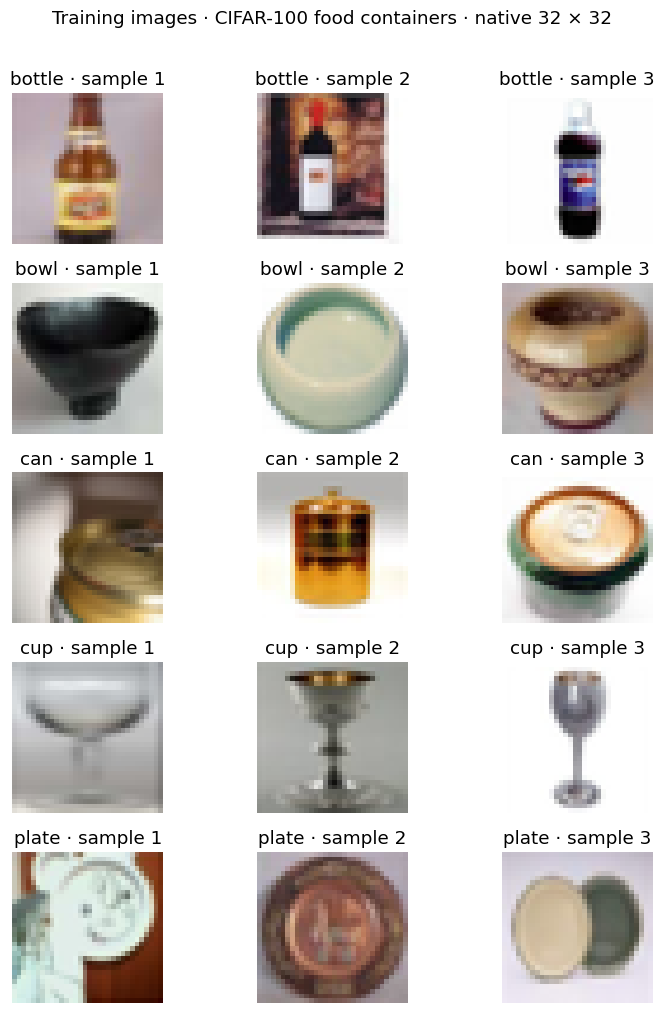

In [26]:
fig, axes = plt.subplots(len(classes), 3, figsize=(8, 2 * len(classes)), squeeze=False)
for label, name in enumerate(classes):
    indices = np.flatnonzero(splits["train"]["labels"] == label)[:3]
    for column, index in enumerate(indices):
        axes[label, column].imshow(splits["train"]["images"][index], interpolation="nearest")
        axes[label, column].set_title(f"{name} · sample {column + 1}")
        axes[label, column].axis("off")
fig.suptitle("Training images · CIFAR-100 food containers · native 32 × 32", y=1.01)
fig.tight_layout()
plt.show()

## 확인 질문과 다음 단계
- 컵과 그릇을 구분하기 어려운 사진에는 어떤 특징이 있나요?
- 같은 촬영 장면을 학습과 테스트에 복사하면 평가가 어떻게 달라질까요?
- 어떤 라이브러리가 파일 다운로드·이미지 변환·배열 저장을 각각 맡았나요?

다음은 `01_gpu_inference.ipynb`입니다. 데이터 출처는 [CIFAR](https://www.cs.toronto.edu/~kriz/cifar.html)와 [고정 데이터 저장소](https://huggingface.co/datasets/uoft-cs/cifar100/tree/aadb3af77e9048adbea6b47c21a81e47dd092ae5)입니다.

## 다음 단계 · Colab GPU에 연결하기
이제 Codespaces에 모델 3개 파일·다운로드 기록·준비 데이터 4개 파일이 있습니다.
[실행 안내](../README.md)를 따라 GPU 세션을 만들고, 이 파일들을 하나씩 올립니다.
그다음 `01_gpu_inference.ipynb`, `02_gpu_finetuning.ipynb`를 공식 Colab CLI로 실행합니다.

첫 추론에서는 `AutoImageProcessor`, `AutoModelForImageClassification`이 모델과 전처리를 불러옵니다.
GPU 노트북을 Codespaces CPU에서 실행해도 원격 GPU로 자동 연결되지는 않습니다.